In [72]:
%load_ext autoreload
%autoreload 2

import datetime
import sys

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import pandas as pd
import QuantLib as ql

plt.style.use("ggplot")
pylab.rcParams.update(
    {
        "legend.fontsize": "x-large",
        "figure.figsize": (18, 8),
        "axes.labelsize": "x-large",
        "axes.titlesize": "x-large",
        "xtick.labelsize": "large",
        "ytick.labelsize": "large",
    }
)

sys.path.append("../../")

from BT.data_handler import TimeGrid
from BT.misc import (
    _last_business_day_of_month,
    _month_iter,
    _n_business_days_before,
    _nth_business_day_of_month,
    ql_cal_date_range,
)
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import DateTrigger, DateTriggerRequirements
from MDP.FixedRateBonds.FixedRateBondsMDP import FixedRateBondsMDP
from Query.Base.query_resolution import resolve_query
from Query.FixedRateBonds.carry_roll import load_us_treasury_gc_fixing_pct
from Query.FixedRateBonds.FixedRateBondQuery import FixedRateBondQuery
from Query.FixedRateBonds.FixedRateBondValue import FixedRateBondValue
from BT.query_tearsheet import QueryBacktestTearSheet

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [73]:
CAL = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
risk_bpv = 100_000
unwind_fee_bps = 1.0 # round trip (0.5bp bid/offer) 

start = datetime.date(2015, 1, 1)
end = datetime.date(2026, 3, 20)

days_pre_month_end = 2
days_after_month_end = 1

cycles = []
for y, m in _month_iter(start, end):
    eom_bd = _last_business_day_of_month(CAL, y, m)
    entry = _n_business_days_before(CAL, eom_bd, days_pre_month_end)
    ny, nm = (y + 1, 1) if m == 12 else (y, m + 1)
    exit_ = _nth_business_day_of_month(CAL, ny, nm, days_after_month_end)

    if entry < start or exit_ > end:
        continue

    cycles.append((entry, exit_, f"me-trade-{y:04d}{m:02d}"))

tg = TimeGrid(
    ql_cal_date_range(
        ql_cal=CAL,
        start=min(entry for entry, _, _ in cycles),
        end=max(exit_ for _, exit_, _ in cycles),
    )
)

gc_fixing_pct = pd.Series(
    {
        d: load_us_treasury_gc_fixing_pct(d)
        for d in sorted({ts.date() for ts in tg})
    },
    dtype=float,
).sort_index()

if gc_fixing_pct.isna().any():
    missing = gc_fixing_pct[gc_fixing_pct.isna()].index.tolist()
    raise ValueError(f"Missing GC fixing data for backtest dates: {missing[:10]}")

financing_config = {
    "mode": "gc_plus_specialness",
    "gc_rate": gc_fixing_pct / 100.0,
    "leg_specialness_bps": {"outright": 10.0},
    "day_count": "ACT/360",
    "haircut": 0.0,
}

frb_mdp = FixedRateBondsMDP(source="USTS_FEDINVEST_WSJ_LIVE-QL")
trade_query = FixedRateBondQuery(
    # cusip="o10/CT10",
    cusip="CT10",
    value=FixedRateBondValue.NPV,
    structure_kwargs={"bpv": risk_bpv},
    meta={"financing": financing_config},
)

len(cycles), cycles[:3]

(134,
 [(datetime.date(2015, 1, 28), datetime.date(2015, 2, 2), 'me-trade-201501'),
  (datetime.date(2015, 2, 25), datetime.date(2015, 3, 2), 'me-trade-201502'),
  (datetime.date(2015, 3, 27), datetime.date(2015, 4, 1), 'me-trade-201503')])

In [74]:
triggers = []
for entry_date, exit_date, tag in cycles:
    tagged_query = FixedRateBondQuery(
        cusip=trade_query.cusip,
        value=trade_query.value,
        structure_kwargs=dict(trade_query.structure_kwargs),
        meta=dict(trade_query.meta),
        tags=(tag,),
    )
    triggers.extend(
        [
            DateTrigger(DateTriggerRequirements(dates=[entry_date]), actions=[AddQueryAction(query=tagged_query)]),
            DateTrigger(
                DateTriggerRequirements(dates=[exit_date]),
                actions=[UnwindPositionsAction(match_tag=tag, fee=unwind_fee_bps * risk_bpv)],
            ),
        ]
    )

strategy = QueryStrategy(name=f"Month-End {trade_query.col_name()}", triggers=triggers)
bt = QueryDrivenBacktest(time_grid=tg, mdp=frb_mdp, strategy=strategy)
bt.run()


BACKTESTING...: 100%|██████████| 2773/2773 [00:04<00:00, 593.27step/s]


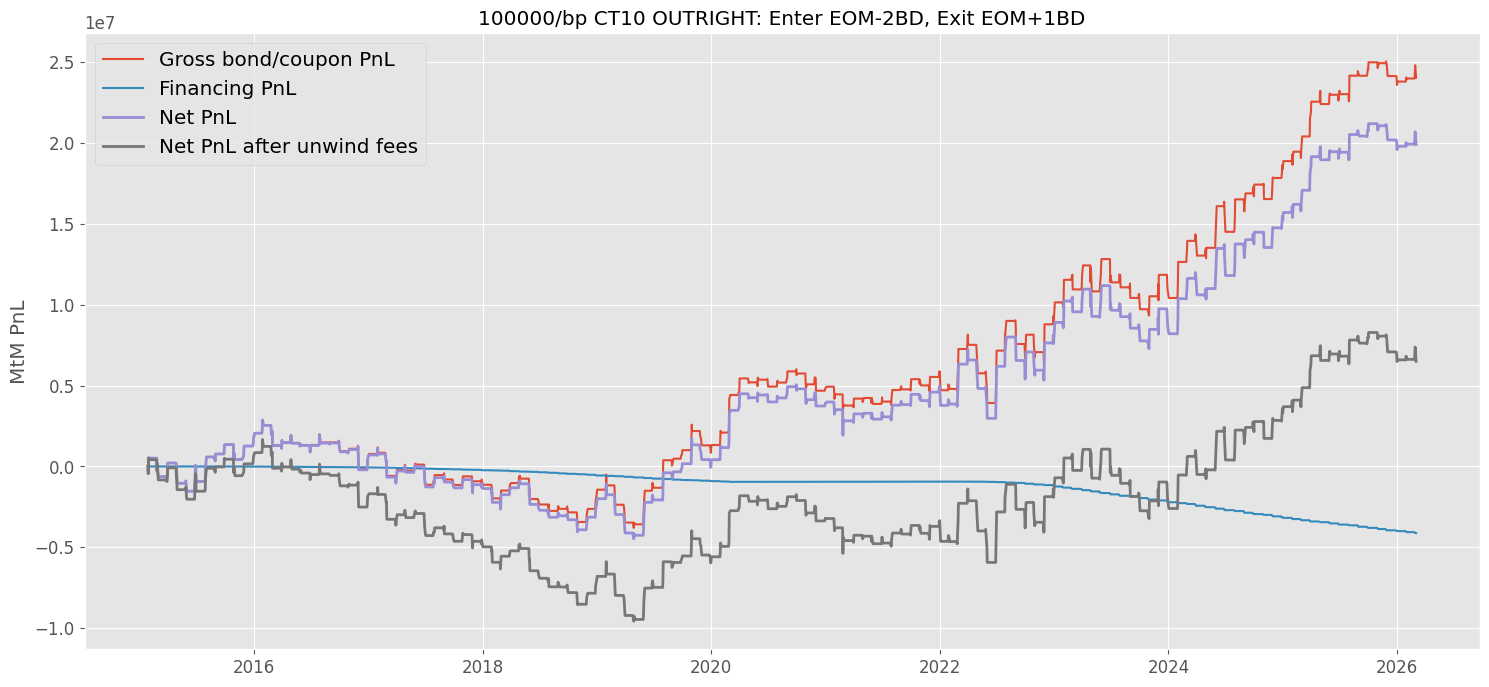

In [75]:
# mtm = pd.Series(bt.mtm_history).sort_index()
# print("Final MTM:", float(mtm.iloc[-1]))

# plt.figure()
# plt.plot(mtm.index, mtm.values, label="MtM PnL")
# plt.legend()
# plt.title(f"{risk_bpv}/bp {trade_query.col_name()[:-4]}: Enter EOM-{days_pre_month_end}BD, Exit EOM+{days_after_month_end}BD")
# plt.show()

time_index = pd.Index(list(tg), name="date")
component_histories = getattr(bt, "frb_component_histories", {})

gross_bond = pd.Series(component_histories.get("bond_total", {}), dtype=float).sort_index()
financing = pd.Series(component_histories.get("financing_total", {}), dtype=float).sort_index()
net = pd.Series(component_histories.get("net_total", {}), dtype=float).sort_index()

gross_bond = gross_bond.reindex(time_index).ffill().fillna(0.0)
financing = financing.reindex(time_index).ffill().fillna(0.0)
net = net.reindex(time_index).ffill().fillna(0.0)
closed = pd.DataFrame(bt.portfolio.closed_positions_log)

if closed.empty:
    unwind_fees = pd.Series(0.0, index=time_index)
else:
    unwind_fees = (
        closed.assign(closed_at=pd.to_datetime(closed["closed_at"]))
        .groupby("closed_at")["fee_allocated"]
        .sum()
        .sort_index()
        .reindex(time_index, fill_value=0.0)
        .cumsum()
    )

net_after_fees = net - unwind_fees

plt.plot(gross_bond.index, gross_bond.values, label="Gross bond/coupon PnL")
plt.plot(financing.index, financing.values, label="Financing PnL")
plt.plot(net.index, net.values, label="Net PnL", linewidth=2)
plt.plot(net_after_fees.index, net_after_fees.values, label="Net PnL after unwind fees", linewidth=2)

plt.title(f"{risk_bpv}/bp {trade_query.col_name()[:-4]}: Enter EOM-{days_pre_month_end}BD, Exit EOM+{days_after_month_end}BD")
plt.ylabel("MtM PnL")
plt.legend(loc="best")

In [76]:
tearsheet = QueryBacktestTearSheet.from_backtest(bt)
# mpl_fig = tearsheet.plot_matplotlib()
plotly_fig = tearsheet.plot_plotly()
plotly_fig.show()
# summary = tearsheet.summary_frame